# 2 · Autoencoders: AE y DAE

**Hipótesis:** un autoencoder entrenado solo con campañas normales reconstruye mal
las anómalas; el **error de reconstrucción** es el score.

Acá entrenamos **AE** (autoencoder) y **DAE** (denoising, reconstruye limpio desde input
corrupto), multi-seed y a la vista. Al final probamos correr **IForest y One-Class SVM
sobre el espacio latente** del AE (la receta "deep representation + shallow detector").

In [1]:
import lab                      # utilidades: métricas y gráficos (experiments/lab.py)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config, data
from src.models import (IsolationForestDetector, OneClassSVMDetector,
                        AEDetector, DenoisingAEDetector, VAEDetector,
                        EnsembleDetector, DeepODDetector)
plt.rcParams["figure.dpi"] = 110
SEEDS = lab.SEEDS            # 10 semillas del estudio. Bajalas (p. ej. [42,43,44])
print("semillas:", SEEDS)   # para un Run all más rápido; los números se mueven ±std

semillas: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


In [2]:
panel_z = data.prepare()                         # panel + etiqueta z_rinde
ds   = data.build_crop_dataset(panel_z, "soja")  # split + normalización (soja)
dsm  = data.build_crop_dataset(panel_z, "maiz")  # idem maíz
print("soja  train:", ds.X_train.shape, "| test anómalas:", int(ds.y_test.sum()))
print("maíz  train:", dsm.X_train.shape, "| test anómalas:", int(dsm.y_test.sum()))

[data] dedup panel: 28683 → 21418 filas (7265 duplicados espurios por lat/lon eliminados)


soja  train: (6377, 54) | test anómalas: 257
maíz  train: (8347, 54) | test anómalas: 349


## 2.1 · Autoencoder (AE)
Encoder comprime las 54 features a un latente de 16, decoder reconstruye, score = MSE.
Entrenamos **una semilla por vuelta** y guardamos las métricas — el loop está a la vista:

In [3]:
filas_ae = []
for seed in SEEDS:
    ae = AEDetector(hidden_dims=(64,32), latent_dim=16, max_epochs=300, patience=30,
                    random_state=seed).fit(ds.X_train)          # entrena de verdad
    scores = ae.score_samples(ds.X_test)                        # error de reconstrucción
    filas_ae.append(lab.metrics(scores, ds.y_test))
print("AE (soja, media±std entre semillas):")
lab.mean_std(filas_ae)

AE (soja, media±std entre semillas):


pr_auc              0.314±0.038
roc_auc             0.558±0.053
prec_at_k           0.322±0.049
recall_at_contam    0.124±0.047
dtype: str

La curva de loss del último AE (entrena bien; el problema no es el fit):

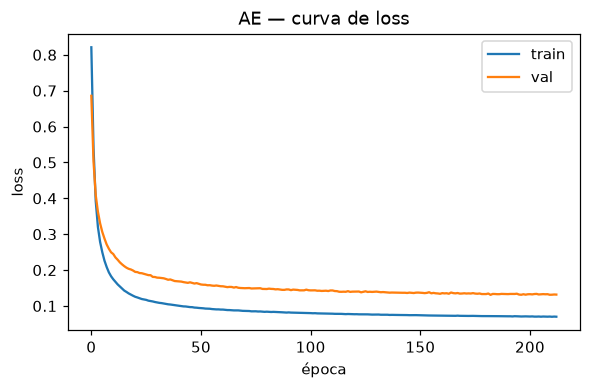

In [4]:
h = pd.DataFrame(ae.history_)
fig, ax = plt.subplots(figsize=(6,3.5))
ax.plot(h["epoch"], h["train_loss"], label="train"); ax.plot(h["epoch"], h["val_loss"], label="val")
ax.set_xlabel("época"); ax.set_ylabel("loss"); ax.legend(); ax.set_title("AE — curva de loss"); plt.show()

## 2.2 · Denoising AE (DAE)
Se corrompe el input y se entrena a reconstruir el limpio → representación más robusta al
ruido:

In [5]:
filas_dae = []
for seed in SEEDS:
    dae = DenoisingAEDetector(hidden_dims=(64,32), latent_dim=16, corruption=0.1,
                              noise_type="salt_pepper", max_epochs=300, patience=30,
                              random_state=seed).fit(ds.X_train)
    filas_dae.append(lab.metrics(dae.score_samples(ds.X_test), ds.y_test))
print("DAE (soja, media±std):")
lab.mean_std(filas_dae)

DAE (soja, media±std):


pr_auc              0.381±0.068
roc_auc             0.634±0.070
prec_at_k           0.415±0.068
recall_at_contam    0.169±0.047
dtype: str

### AE vs DAE vs baseline

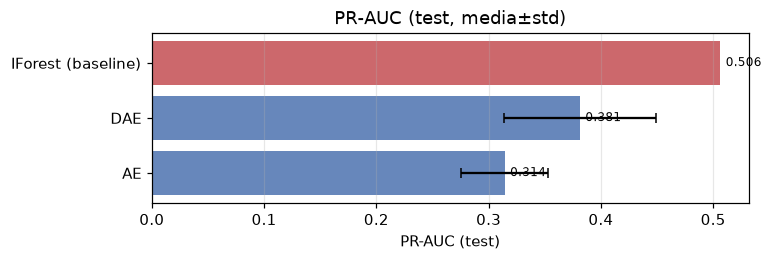

,modelo,pr_auc,pr_auc_std,roc_auc
0,IForest (baseline),0.506,NaN,0.701
1,DAE,0.381,0.068,0.634
2,AE,0.314,0.038,0.558


In [6]:
resumen = lab.leaderboard({
    "IForest (baseline)": [lab.metrics(IsolationForestDetector(n_estimators=200, max_features=0.3)
                                       .fit(ds.X_train).score_samples(ds.X_test), ds.y_test)],
    "AE": filas_ae, "DAE": filas_dae})
lab.plot_leaderboard(resumen); plt.show()
resumen[["modelo","pr_auc","pr_auc_std","roc_auc"]].round(3)

Ambos quedan por debajo del baseline: el **error de reconstrucción con MSE no alcanza**.
El problema no es la arquitectura (se probaron 24 variantes en la exploración, todas
en un rango estrecho) sino el *score* — lo resolvemos con el VAE en el nb 3.

## 2.3 · IForest y OCSVM sobre el latente del AE
Idea de la literatura: usar el AE solo para **comprimir** y correr un detector shallow en
el espacio latente (16 dim), donde el ruido de features redundantes ya se descartó.
Entrenamos un AE, sacamos el latente con `.encode()`, y corremos los detectores ahí:

In [7]:
ae = AEDetector(hidden_dims=(64,32), latent_dim=16, max_epochs=300, patience=30,
                random_state=42).fit(ds.X_train)
Ztr, Zte = ae.encode(ds.X_train), ae.encode(ds.X_test)   # espacio latente (16 dim)
print("latente:", Ztr.shape)
for nombre, det in [("IForest sobre latente", IsolationForestDetector(n_estimators=200, max_features=0.3)),
                    ("OCSVM-RBF sobre latente", OneClassSVMDetector(kernel="rbf", nu=0.1))]:
    det.fit(Ztr)
    m = lab.metrics(det.score_samples(Zte), ds.y_test)
    print(f"{nombre:26s} PR-AUC={m['pr_auc']:.3f}  ROC={m['roc_auc']:.3f}")

latente: (6377, 16)
IForest sobre latente      PR-AUC=0.346  ROC=0.581
OCSVM-RBF sobre latente    PR-AUC=0.445  ROC=0.624


**No mejora sobre el baseline.** El bottleneck del AE (entrenado por MSE) destruye la
estructura que el detector necesita: comprimir a un latente optimizado para reconstruir no
preserva la señal de anomalía. Guardamos la idea — con el VAE (nb 3) el latente es mejor,
pero ni así supera al score `recon_prob` directo.

**Conclusión:** AE/DAE con MSE no alcanzan, ni directo ni vía latente. **El problema es el
score, no la arquitectura** → nb 3.